In [3]:
import cv2
import numpy as np

In [4]:
def image_to_point_cloud(image_path, n_points=2048):
    # Load and binarize
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Get all active pixel locations (y, x)
    coords = np.column_stack(np.where(binary > 0))
    
    # Randomly sample n_points
    if len(coords) >= n_points:
        indices = np.random.choice(len(coords), n_points, replace=False)
    else:
        # If shape has fewer pixels than n_points, sample with replacement
        indices = np.random.choice(len(coords), n_points, replace=True)
    
    sampled_coords = coords[indices].astype(float)
    
    # Normalize to [-1, 1] range and flip Y to match Cartesian coordinates
    h, w = img.shape
    sampled_coords[:, 0] = 1.0 - (sampled_coords[:, 0] / h) * 2.0  # Normalized Y (flipped)
    sampled_coords[:, 1] = (sampled_coords[:, 1] / w) * 2.0 - 1.0  # Normalized X
    
    # Swap columns to return (x, y) format
    return sampled_coords[:, [1, 0]]

# Example usage
cloud = image_to_point_cloud('img1.jpg', n_points=1024)

Text(0.5, 1.0, 'Point Cloud from Image')

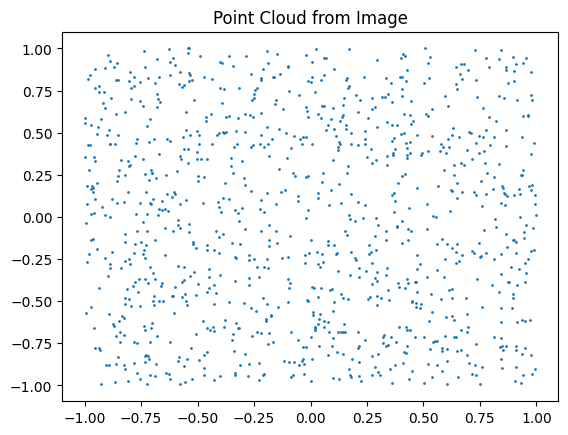

In [5]:
import matplotlib.pyplot as plt
plt.scatter(cloud[:, 0], cloud[:, 1], s=1)
plt.title('Point Cloud from Image')

In [7]:
def image_to_point_cloud(image_path, n_points=2048, sigma=0.01, clip=0.05):
    """
    Converts image to point cloud with Gaussian Jittering.
    
    Args:
        image_path: Path to the image.
        n_points: Number of points to sample.
        sigma: Standard deviation of the Gaussian noise (jitter).
        clip: Maximum value to clip the noise (prevents extreme outliers).
    """
    # 1. Load and binarize
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found.")
        
    # Assuming black background, white digit. Use cv2.THRESH_BINARY_INV if inverted.
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    
    # 2. Get all active pixel locations (y, x)
    coords = np.column_stack(np.where(binary > 0))
    
    # 3. Randomly sample n_points
    if len(coords) == 0:
        return np.zeros((n_points, 2))
        
    indices = np.random.choice(len(coords), n_points, replace=(len(coords) < n_points))
    sampled_coords = coords[indices].astype(float)
    
    # 4. Normalize to [-1, 1] range
    h, w = img.shape
    # Normalized Y (flipped) and X
    sampled_coords[:, 0] = 1.0 - (sampled_coords[:, 0] / h) * 2.0  
    sampled_coords[:, 1] = (sampled_coords[:, 1] / w) * 2.0 - 1.0  
    
    # Swap columns to (x, y) format
    points = sampled_coords[:, [1, 0]]

    # 5. ADD JITTERING NOISE
    # This is the standard augmentation used in PointNet/ModelNet40 research
    if sigma > 0:
        noise = np.clip(np.random.normal(0, sigma, size=points.shape), -1 * clip, clip)
        points += noise
    
    return points

# Example usage for ModelNet40-style preprocessing
cloud = image_to_point_cloud('img1.jpg', n_points=1024, sigma=0.05, clip=0.1)

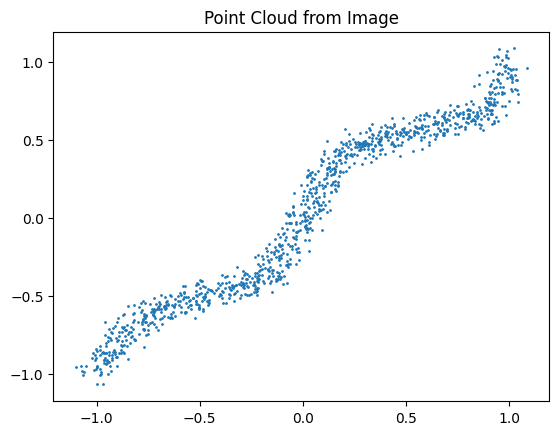

In [8]:
plt.scatter(cloud[:, 0], cloud[:, 1], s=1)
plt.title('Point Cloud from Image')
plt.show()


In [17]:
pt_cld_data = np.zeros((100, 1024, 2))  
for i in range(10):
    img_path = f'digits imgs/digit {i}.jpg'
    for j in range(10):
        print(f'Processing {img_path} (sample {j})...')
        cloud = image_to_point_cloud(img_path, n_points=1024, sigma=0.02, clip=0.1)
        pt_cld_data[10 * i + j] = cloud

Processing digits imgs/digit 0.jpg (sample 0)...
Processing digits imgs/digit 0.jpg (sample 1)...
Processing digits imgs/digit 0.jpg (sample 2)...
Processing digits imgs/digit 0.jpg (sample 3)...
Processing digits imgs/digit 0.jpg (sample 4)...
Processing digits imgs/digit 0.jpg (sample 5)...
Processing digits imgs/digit 0.jpg (sample 6)...
Processing digits imgs/digit 0.jpg (sample 7)...
Processing digits imgs/digit 0.jpg (sample 8)...
Processing digits imgs/digit 0.jpg (sample 9)...
Processing digits imgs/digit 1.jpg (sample 0)...
Processing digits imgs/digit 1.jpg (sample 1)...
Processing digits imgs/digit 1.jpg (sample 2)...
Processing digits imgs/digit 1.jpg (sample 3)...
Processing digits imgs/digit 1.jpg (sample 4)...
Processing digits imgs/digit 1.jpg (sample 5)...
Processing digits imgs/digit 1.jpg (sample 6)...
Processing digits imgs/digit 1.jpg (sample 7)...
Processing digits imgs/digit 1.jpg (sample 8)...
Processing digits imgs/digit 1.jpg (sample 9)...
Processing digits im

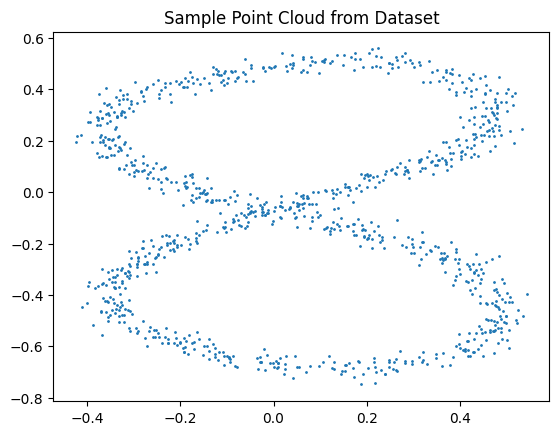

In [18]:
cloud = pt_cld_data[88]
plt.scatter(cloud[:, 0], cloud[:, 1], s=1)
plt.title('Sample Point Cloud from Dataset')    
plt.show()

In [19]:
np.save('digits_pointcloud_data_sig_0.02_clip_0.1.npy', pt_cld_data)

In [ ]:
pt_cld_data = np.zeros((100, 1024, 2))  
for i in range(10):
    img_path = f'digits imgs/digit {i}.jpg'
    for j in range(10):
        #print(f'Processing {img_path} (sample {j})...')
        cloud = image_to_point_cloud(img_path, n_points=1024, sigma=0.1, clip=0.2)
        pt_cld_data[10 * i + j] = cloud

Processing digits imgs/digit 0.jpg (sample 0)...
Processing digits imgs/digit 0.jpg (sample 1)...
Processing digits imgs/digit 0.jpg (sample 2)...
Processing digits imgs/digit 0.jpg (sample 3)...
Processing digits imgs/digit 0.jpg (sample 4)...
Processing digits imgs/digit 0.jpg (sample 5)...
Processing digits imgs/digit 0.jpg (sample 6)...
Processing digits imgs/digit 0.jpg (sample 7)...
Processing digits imgs/digit 0.jpg (sample 8)...
Processing digits imgs/digit 0.jpg (sample 9)...
Processing digits imgs/digit 1.jpg (sample 0)...
Processing digits imgs/digit 1.jpg (sample 1)...
Processing digits imgs/digit 1.jpg (sample 2)...
Processing digits imgs/digit 1.jpg (sample 3)...
Processing digits imgs/digit 1.jpg (sample 4)...
Processing digits imgs/digit 1.jpg (sample 5)...
Processing digits imgs/digit 1.jpg (sample 6)...
Processing digits imgs/digit 1.jpg (sample 7)...
Processing digits imgs/digit 1.jpg (sample 8)...
Processing digits imgs/digit 1.jpg (sample 9)...
Processing digits im

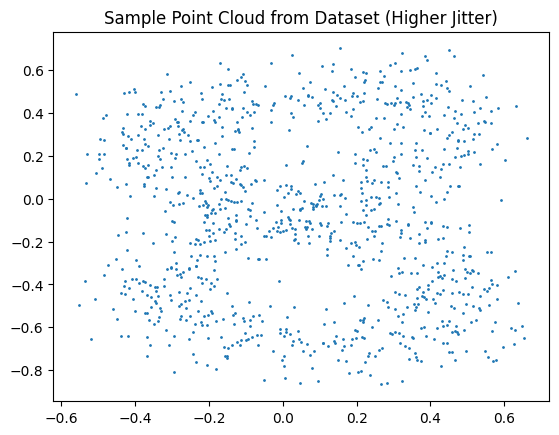

In [15]:
cloud = pt_cld_data[88]
plt.scatter(cloud[:, 0], cloud[:, 1], s=1)
plt.title('Sample Point Cloud from Dataset (Higher Jitter)')    
plt.show()

In [16]:
np.save('digits_pointcloud_data_sig_0.1_clip_0.2.npy', pt_cld_data)

In [18]:
pt_cld_data = np.zeros((100, 1024, 2))  
for i in range(10):
    img_path = f'digits imgs/digit {i}.jpg'
    for j in range(10):
        #print(f'Processing {img_path} (sample {j})...')
        cloud = image_to_point_cloud(img_path, n_points=1024, sigma=0.075, clip=0.2)
        pt_cld_data[10 * i + j] = cloud

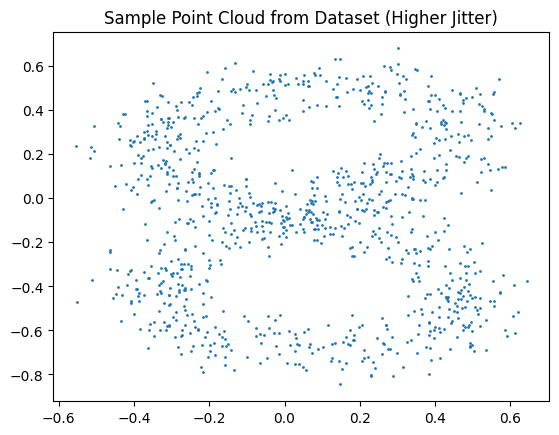

In [19]:
cloud = pt_cld_data[88]
plt.scatter(cloud[:, 0], cloud[:, 1], s=1)
plt.title('Sample Point Cloud from Dataset (Higher Jitter)')
plt.show()


In [20]:
np.save('digits_pointcloud_data_sig_0.075_clip_0.2.npy', pt_cld_data)